**EQUIPO 51**

Elliot Nez Arredondo | A01796107

Luis Antonio Calderon Mata | A00278401


Fernando Guzman Briones | A01039274

#**Activación de drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Incluye todas las librerías que consideres adecuadas:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import fbeta_score, make_scorer
from imblearn.metrics import geometric_mean_score
import statistics # import the statistics module from the standard library
from numpy import std
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from statistics import mean
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score
import time # Import the time module

# Define MAPE function once globally
def mean_absolute_percentage_error(y_true, y_pred):
    epsilon = np.finfo(np.float64).eps
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, epsilon))) * 100

# Initialize a list to store metrics for all models globally
all_model_metrics = []


In [ ]:
path = '/content/drive/MyDrive/Proyecto Integrador/NBS_Mod_QR Orders December 2025(OERP (NBS)).csv'
df = read_csv(path, header=0, encoding='latin1')

In [ ]:
#Luis
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador"
os.chdir(DIR)
df = pd.read_csv('NBS_Mod_QR Orders December 2025.csv')

In [ ]:
df.head()

,Group,District,Region,Date,Month,Region Vlookup,District Vlookup,Branch Vlookup,Change Order Lookup,PROJECT,...,Unnamed: 35,Plan -2 Costs,Plan -2 CMII $,Plan -2 CMII%,MP?,CMII %,Change Order?,Product,DISTRICT,Branch Name
0,10100.0,Central West,West,12/31/2025,12.0,ALL REGIONSAll OrdersAD12,Central WestAll OrdersAD12,10100All OrdersAD12,All Orders,6741283.0,...,NaN,NaN,NaN,NaN,No,40.74%,Yes,Addwork,DMD,San Antonio
1,10414.0,Central,East,12/31/2025,12.0,ALL REGIONSAll OrdersNE12,CentralAll OrdersNE12,10414All OrdersNE12,All Orders,6741284.0,...,NaN,NaN,NaN,NaN,No,100.00%,Yes,MonoSpace 500 2-3 landing(ENA),DCE,Nashville
2,10414.0,Central,East,12/31/2025,12.0,ALL REGIONSAll OrdersNE12,CentralAll OrdersNE12,10414All OrdersNE12,All Orders,6741284.0,...,NaN,NaN,NaN,NaN,No,100.00%,Yes,MonoSpace 500 2-3 landing(ENA),DCE,Nashville
3,10100.0,Central West,West,12/31/2025,12.0,ALL REGIONSAll OrdersAD12,Central WestAll OrdersAD12,10100All OrdersAD12,All Orders,6753566.0,...,NaN,NaN,NaN,NaN,No,46.05%,Yes,Addwork,DMD,San Antonio
4,10260.0,Central,East,12/31/2025,12.0,ALL REGIONSAll OrdersTM12,CentralAll OrdersTM12,10260All OrdersTM12,All Orders,6772984.0,...,NaN,NaN,NaN,NaN,No,68.71%,Yes,Time and material,DCE,Grand Rapids


In [ ]:
# Primero procedemos con una limpieza de datos

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Make column names unique if there are duplicates after stripping
cols = pd.Series(df.columns)
duplicate_mask = cols.duplicated(keep=False)
if duplicate_mask.any():
    new_columns = []
    counts = {}
    for col_name in cols:
        if col_name in counts:
            counts[col_name] += 1
            new_columns.append(f'{col_name}.{counts[col_name]}')
        else:
            counts[col_name] = 0
            new_columns.append(col_name)
    df.columns = new_columns

# Correct specific column name 'CMII %' to 'CMII%' if it exists (this should be handled by stripping and uniqueness now, but kept for robustness)
if 'CMII %' in df.columns:
    df.rename(columns={'CMII %': 'CMII%'}, inplace=True)



# objetivos a limpiar
# Update target_cols to reflect potential unique names if CMII% was duplicated.
# For now, let's keep the original names, assuming the uniqueness step will handle the DataFrame side.
target_cols = ['MV', 'CMII $', 'PLAN COSTS', 'CMII%']

def clean_currency_and_percent(val):
    # If val is an array-like object (e.g., a Series), it means the data is malformed.
    # Return NaN as it cannot be cleaned as a single currency/percentage string.
    if isinstance(val, (list, tuple, np.ndarray, pd.Series)):
        return np.nan

    # Handle NaN or empty string values first
    if pd.isna(val) or (isinstance(val, str) and val.strip() == '') or val == '-':
        # Treat '-' as 0.0 for accounting context, otherwise NaN for truly missing
        return 0.0 if val == '-' else np.nan

    if isinstance(val, str):
        val = val.strip()
        # Handle parentheses for negatives: (1,234.56) -> -1234.56
        if val.startswith('(') and val.endswith(')'):
            val = '-' + val[1:-1]
        # Remove symbols
        val = val.replace('$', '').replace('%', '').replace(',', '')
        try:
            return float(val)
        except ValueError:
            return np.nan
    else:
        # If it's not a string and not NaN/empty/array-like, it might be a number already.
        # Attempt to convert to float in case it's an int or other numeric type.
        try:
            return float(val)
        except (ValueError, TypeError):
            return np.nan # Unparseable non-string, non-NaN scalar

# Aplicar limpieza
for col in target_cols:
    if col in df.columns: # Check if column exists after potential renaming of duplicates
        df[col] = df[col].apply(clean_currency_and_percent)
    else:
        print(f"Warning: Column '{col}' not found after cleaning column names.")

# Eliminar registros donde MV sea NaN o vacío
# Eliminar símbolos comunes
df["MV"] = (
    df["MV"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convertir a numérico
df["MV"] = pd.to_numeric(df["MV"], errors="coerce")

# Eliminar filas donde 'Change Order' es 'Yes'
if 'Change Order?' in df.columns:
    df = df[df['Change Order?'] != 'Yes'].copy()
    print(f"Filtered out rows where 'Change Order?' is 'Yes'. New shape: {df.shape}")
else:
    print("Warning: 'Change Order?' column not found. Skipping filtering by 'Change Order?'.")

# Ver cuántos NaN hay ahora
print("NaN en MV:", df["MV"].isna().sum())

# Eliminar filas con NaN en MV
df = df.dropna(subset=["MV"])

# Resumen
# Filter target_cols to only include columns that actually exist in the DataFrame
existing_target_cols = [col for col in target_cols if col in df.columns]

stats = df[existing_target_cols].describe()
missing_values = df[existing_target_cols].isna().sum()

print("Descriptive Statistics after cleaning:")
print(stats)
print("\nMissing values per column:")
print(missing_values)

# datos limpios en un nuevo csv
cleaned_file_name = 'Cleaned_NBS_Orders_Targets.csv'
df.to_csv(cleaned_file_name, index=False)

print(f"\nCleaned file saved as: {cleaned_file_name}")
print("Shape final:", df.shape)


/tmp/ipykernel_2255/3863279236.py:70: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df[col] = df[col].apply(clean_currency_and_percent)


Filtered out rows where 'Change Order?' is 'Yes'. New shape: (14582, 45)
NaN en MV: 4964
Descriptive Statistics after cleaning:
                 MV        CMII $    PLAN COSTS  CMII%  CMII%
count  9.618000e+03  7.804000e+03  9.473000e+03    0.0    0.0
mean   1.399279e+05  4.074681e+04  1.246566e+05    NaN    NaN
std    2.713520e+06  1.383335e+06  4.174359e+06    NaN    NaN
min    1.000000e-02  1.000000e-02  1.000000e-02    NaN    NaN
25%    4.283788e+03  1.387568e+03  2.813130e+03    NaN    NaN
50%    1.617610e+04  1.258351e+04  1.262408e+04    NaN    NaN
75%    1.553688e+05  2.838961e+04  1.320388e+05    NaN    NaN
max    2.295369e+08  1.205262e+08  4.061443e+08    NaN    NaN

Missing values per column:
MV               0
CMII $        1814
PLAN COSTS     145
CMII%         9618
CMII%         9618
dtype: int64

Cleaned file saved as: Cleaned_NBS_Orders_Targets.csv
Shape final: (9618, 45)


In [ ]:
if 'Change Order?' in df.columns:
    print(f"Unique values for 'Change Order?': {df['Change Order?'].unique()}")
    print(f"Counts for 'Change Order?':\n{df['Change Order?'].value_counts()}")
    print(f"Data type of 'Change Order?': {df['Change Order?'].dtype}")
else:
    print("Column 'Change Order?' not found in the DataFrame.")

Unique values for 'Change Order?': [' Yes ' ' No ' nan]
Counts for 'Change Order?':
Change Order?
No      6083
Yes     3523
Name: count, dtype: int64
Data type of 'Change Order?': object


In [ ]:
if 'Product' in df.columns:
    # Strip whitespace from 'Product' column values
    df['Product'] = df['Product'].str.strip()

    # List of product types to exclude
    excluded_products = ['Addwork', 'Project Expense', 'Others', 'Temp Use', 'Time and material']

    # Filter out rows where 'Product' column is in the excluded_products list
    initial_rows = df.shape[0]
    df = df[~df['Product'].isin(excluded_products)].copy()
    final_rows = df.shape[0]
    print(f"Removed {initial_rows - final_rows} rows based on 'Product' exclusion.")
    print(f"New DataFrame shape: {df.shape}")
else:
    print("Column 'Product' not found in the DataFrame. No filtering applied.")

Removed 4372 rows based on 'Product' exclusion.
New DataFrame shape: (5246, 45)


In [ ]:
if 'Change Order?' in df.columns:
    # Strip whitespace from 'Change Order?' values before comparison
    df['Change Order?'] = df['Change Order?'].str.strip()
    df = df[df['Change Order?'] != 'Yes'].copy()
    print(f"Filtered out rows where 'Change Order?' is 'Yes'. New shape: {df.shape}")
    # Save the modified DataFrame to CSV
    cleaned_file_name = 'Cleaned_NBS_Orders_Targets.csv'
    df.to_csv(cleaned_file_name, index=False)
    print(f"Updated DataFrame saved as: {cleaned_file_name}")
    print(f"Current 'Change Order?' value counts:\n{df['Change Order?'].value_counts()}")
else:
    print("Column 'Change Order?' not found in the DataFrame. No filtering applied.")

Filtered out rows where 'Change Order?' is 'Yes'. New shape: (3511, 45)
Updated DataFrame saved as: Cleaned_NBS_Orders_Targets.csv
Current 'Change Order?' value counts:
Change Order?
No    3499
Name: count, dtype: int64


In [ ]:
df = pd.read_csv('Cleaned_NBS_Orders_Targets.csv')

In [ ]:
df.head()

,Group,District,Region,Date,Month,Region Vlookup,District Vlookup,Branch Vlookup,Change Order Lookup,PROJECT,...,Unnamed: 35,Plan -2 Costs,Plan -2 CMII $,Plan -2 CMII%,MP?,CMII%.1,Change Order?,Product,DISTRICT,Branch Name
0,10381.0,Pacific,West,12/30/2025,12.0,ALL REGIONSAll OrdersNM12,PacificAll OrdersNM12,10381All OrdersNM12,All Orders,6865446.0,...,$-,"$234,061.20","$41,515.80",15.07,No,NaN,No,MonoSpace 500 4-6 landing(ENA),DPP,San Francisco
1,10130.0,Pacific,West,12/29/2025,12.0,ALL REGIONSAll OrdersNM12,PacificAll OrdersNM12,10130All OrdersNM12,All Orders,6867274.0,...,$-,"$214,947.44","$33,385.04",13.44,No,NaN,No,MonoSpace 500 4-6 landing(ENA),DPP,San Diego
2,10130.0,Pacific,West,12/29/2025,12.0,ALL REGIONSAll OrdersNM12,PacificAll OrdersNM12,10130All OrdersNM12,All Orders,6867274.0,...,$-,"$214,682.44","$33,656.04",13.55,No,NaN,No,MonoSpace 500 4-6 landing(ENA),DPP,San Diego
3,10130.0,Pacific,West,12/29/2025,12.0,ALL REGIONSAll OrdersNM12,PacificAll OrdersNM12,10130All OrdersNM12,All Orders,6867274.0,...,$-,"$215,370.05","$29,603.23",12.08,No,NaN,No,MonoSpace 500 4-6 landing(ENA),DPP,San Diego
4,10130.0,Pacific,West,12/29/2025,12.0,ALL REGIONSAll OrdersNM12,PacificAll OrdersNM12,10130All OrdersNM12,All Orders,6867274.0,...,$-,"$215,370.05","$29,603.23",12.08,No,NaN,No,MonoSpace 500 4-6 landing(ENA),DPP,San Diego


#**Modelo 1 :XGBoost base**

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Data preparation for X and y
df_model = df.dropna(subset=['PROJECT NAME']).copy()

# Clean 'Plan -2 Costs' to ensure it's numeric before using it in X
if 'Plan -2 Costs' in df_model.columns:
    df_model['Plan -2 Costs'] = df_model['Plan -2 Costs'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
    df_model['Plan -2 Costs'] = df_model['Plan -2 Costs'].apply(lambda x: '-' + x[1:-1] if isinstance(x, str) and x.startswith('(') and x.endswith(')') else x)
    df_model['Plan -2 Costs'] = pd.to_numeric(df_model['Plan -2 Costs'], errors='coerce')
    df_model['Plan -2 Costs'] = df_model['Plan -2 Costs'].fillna(df_model['Plan -2 Costs'].median())

features_to_encode = ['District', 'Region', 'EQUIP TYPE', 'PROD CODE'] # Categorical features
numerical_features = ['Month', 'Plan -2 Costs'] # Numerical features

X_categorical = pd.get_dummies(df_model[features_to_encode], drop_first=True)
X_numerical = df_model[numerical_features]
X = pd.concat([X_categorical, X_numerical], axis=1)
y = df_model['MV']

# 1. Preparación de variables (X e y ya definidos)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Configuración del modelo XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

start_time = time.time()
# 3. Entrenamiento
xgb_model.fit(X_train, y_train)

# 4. Predicción
y_pred = xgb_model.predict(X_test)
end_time = time.time()
xgb_execution_time = end_time - start_time

# 5. Métricas
xgb_r2 = r2_score(y_test, y_pred)
xgb_mae = mean_absolute_error(y_test, y_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
xgb_mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"R2 Score: {xgb_r2:.4f}")
print(f"MAE: {xgb_mae:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"MAPE: {xgb_mape:.2f}%")
print(f"Execution Time: {xgb_execution_time:.2f} seconds")

# 6. Importancia de variables
importances = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nVariables más importantes:")
print(importances.head(5))

# Store metrics
all_model_metrics.append({
    'Model': 'XGBoost Regressor',
    'R2 Score': xgb_r2,
    'MAE': xgb_mae,
    'RMSE': xgb_rmse,
    'MAPE (%)': xgb_mape,
    'Execution Time (s)': xgb_execution_time
})

R2 Score: 0.9459
MAE: 13007.40
RMSE: 42193.38
MAPE: 4.84%
Execution Time: 0.12 seconds

Variables más importantes:
PROD CODE_ HR     0.423299
Plan -2 Costs     0.219947
PROD CODE_ EM     0.080501
PROD CODE_ EX     0.054156
PROD CODE_ NH     0.047669
dtype: float32


In [ ]:
#y_train_log = np.log1p(y_train)
#y_test_log = np.log1p(y_test)

#optimized_xgb = XGBRegressor(
#    n_estimators=1000,        # Aumentamos árboles
#    learning_rate=0.02,       # Bajamos tasa de aprendizaje
#    max_depth=6,
#    subsample=0.8,
#    colsample_bytree=0.8,
#    gamma=0.1,
#    reg_lambda=2.0,           # Mayor regularización L2
#    objective="reg:squarederror",
#    tree_method="hist",
#    early_stopping_rounds=50
#)

# Fit the model before predicting
#optimized_xgb.fit(X_train, y_train_log, eval_set=[(X_test, y_cualtest_log)], verbose=False)

# Al predecir, no olvides:
#y_pred = np.expm1(optimized_xgb.predict(X_test))

##Modelo 1a: Stacking homogeneo ( utilizando mismo XGboost con diferentes hiperparametros)

In [ ]:
#Luis
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
import time

xgb1 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb2 = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=43
)

xgb3 = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=44
)

xgb4 = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=7,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=45
)

base_models = [
    ('xgb1', xgb1),
    ('xgb2', xgb2),
    ('xgb3', xgb3),
    ('xgb4', xgb4)
]

meta_model = Ridge(alpha=1.0)

stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    passthrough=True,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)

y_pred = stacking_model.predict(X_test)

stack_r2 = r2_score(y_test, y_pred)
stack_mae = mean_absolute_error(y_test, y_pred)
stack_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
stack_mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Stacking R2 Score: {stack_r2:.4f}")
print(f"Stacking MAE: {stack_mae:.2f}")
print(f"Stacking RMSE: {stack_rmse:.2f}")
print(f"Stacking MAPE: {stack_mape:.2f}%")

# Store metrics
all_model_metrics.append({
    'Model': 'Stacking Regressor',
    'R2 Score': stack_r2,
    'MAE': stack_mae,
    'RMSE': stack_rmse,
    'MAPE (%)': stack_mape,
    'Execution Time (s)': xgb_stackingexecution_time # Execution time not directly measured in this snippet
})

Stacking R2 Score: 0.9356
Stacking MAE: 14520.63
Stacking RMSE: 46039.75
Stacking MAPE: 5.33%
Execution Time: 13.28 seconds


##1b) Utilzando Voting Regressor (Homogeneo)

In [ ]:
from xgboost import XGBRegressor
import time

xgb1 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb2 = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=43
)

xgb3 = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=44
)

xgb4 = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=7,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=45
)

from sklearn.ensemble import VotingRegressor

voting_model = VotingRegressor(
    estimators=[
        ('xgb1', xgb1),
        ('xgb2', xgb2),
        ('xgb3', xgb3),
        ('xgb4', xgb4)
    ],
    n_jobs=-1
)

start_time = time.time()
voting_model.fit(X_train, y_train)
y_pred = voting_model.predict(X_test)
end_time = time.time()
voting_execution_time = end_time - start_time

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

voting_r2 = r2_score(y_test, y_pred)
voting_mae = mean_absolute_error(y_test, y_pred)
voting_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
voting_mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Voting R2 Score: {voting_r2:.4f}")
print(f"Voting MAE: {voting_mae:.2f}")
print(f"Voting RMSE: {voting_rmse:.2f}")
print(f"Voting MAPE: {voting_mape:.2f}%")
print(f"Execution Time: {voting_execution_time:.2f} seconds")

all_model_metrics.append({
    'Model': 'Voting Regressor (XGBoost)',
    'R2 Score': voting_r2,
    'MAE': voting_mae,
    'RMSE': voting_rmse,
    'MAPE (%)': voting_mape,
    'Execution Time (s)': voting_execution_time
})

Voting R2 Score: 0.9462
Voting MAE: 12740.77
Voting RMSE: 42084.97
Voting MAPE: 4.68%
Execution Time: 3.50 seconds


#Para en analisis del primr modelo base XGBoost modificado mediante tecnicas de ensamble homogeneas, el modelo Voting Regressor presentó el mejor desempeño global, alcanzando un R² de 0.9462 y los menores errores MAE, RMSE y MAPE. Esto indica que, para este conjunto de datos, la agregación simple de múltiples modelos XGBoost con configuraciones distintas resulta más efectiva que el uso de un modelo de stacking, el cual introduce mayor complejidad sin aportar mejoras en la capacidad predictiva. Además, el Voting Regressor mostró un menor tiempo de ejecución, lo que lo convierte en una solución más eficiente computacionalmente.

#**Modelo 2: KNN base**

In [ ]:
# Re-executing K-Nearest Neighbors (KNN) to collect metrics
import time
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

df_model = df.dropna(subset=['PROJECT NAME']).copy()

# Clean 'Plan -2 Costs' to ensure it's numeric before using it in X
if 'Plan -2 Costs' in df_model.columns:
    df_model['Plan -2 Costs'] = df_model['Plan -2 Costs'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
    df_model['Plan -2 Costs'] = df_model['Plan -2 Costs'].apply(lambda x: '-' + x[1:-1] if isinstance(x, str) and x.startswith('(') and x.endswith(')') else x)
    df_model['Plan -2 Costs'] = pd.to_numeric(df_model['Plan -2 Costs'], errors='coerce')
    df_model['Plan -2 Costs'] = df_model['Plan -2 Costs'].fillna(df_model['Plan -2 Costs'].median()) # Fixed: Removed inplace=True

features_to_encode = ['District', 'Region', 'EQUIP TYPE', 'PROD CODE'] # Categorical features
numerical_features = ['Month', 'Plan -2 Costs'] # Numerical features

X_categorical = pd.get_dummies(df_model[features_to_encode], drop_first=True)
X_numerical = df_model[numerical_features]
X = pd.concat([X_categorical, X_numerical], axis=1)
y = df_model['MV']

# 1. Preparar datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Pipeline (Escalamiento + KNN)
knn_pipeline = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(
        n_neighbors=5,
        weights='distance'
    )
)

start_time = time.time()
# 3. Entrenamiento
knn_pipeline.fit(X_train, y_train)

# 4. Predicción
y_pred = knn_pipeline.predict(X_test)
end_time = time.time()
knn_execution_time = end_time - start_time

# 5. Métricas básicas
knn_r2 = r2_score(y_test, y_pred)
knn_mae = mean_absolute_error(y_test, y_pred)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# The mean_absolute_percentage_error function is now defined globally in RZhopTnONk1z
knn_mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"KNN R2 Score: {knn_r2:.4f}")
print(f"KNN MAE: {knn_mae:.2f}")
print(f"KNN RMSE: {knn_rmse:.2f}")
print(f"KNN MAPE: {knn_mape:.2f}%")
print(f"Execution Time: {knn_execution_time:.2f} seconds")

# Store metrics
all_model_metrics.append({
    'Model': 'K-Nearest Neighbors (KNN)',
    'R2 Score': knn_r2,
    'MAE': knn_mae,
    'RMSE': knn_rmse,
    'MAPE (%)': knn_mape,
    'Execution Time (s)': knn_execution_time
})


KNN R2 Score: 0.9231
KNN MAE: 14723.33
KNN RMSE: 50281.81
KNN MAPE: 5.13%
Execution Time: 0.08 seconds


In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

knn_optimized_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)), # Retiene el 95% de la varianza explicada
    ("knn", KNeighborsRegressor(n_neighbors=3, weights='distance', p=2))
])

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import RobustScaler # Mejor que StandardScaler ante outliers
from sklearn.pipeline import Pipeline

# Cambiamos a RobustScaler para proteger las distancias de los costos extremos
knn_advanced_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("knn", KNeighborsRegressor())
])

param_grid_advanced = {
    "knn__n_neighbors": [3, 4, 5, 7],
    "knn__weights": ["distance"],
    # Probamos p=1 (Manhattan) y p=2 (Euclidiana)
    "knn__p": [1, 2],
    # Probamos algoritmos de búsqueda para optimizar el tiempo de ejecución (s)
    "knn__algorithm": ["ball_tree", "kd_tree", "auto"]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search_knn = GridSearchCV(
    estimator=knn_advanced_pipeline,
    param_grid=param_grid_advanced,
    scoring="neg_mean_absolute_percentage_error", # Minimizamos el MAPE directamente
    cv=cv,
    n_jobs=-1,
    verbose=1
)

search_knn.fit(X_train, y_train)
print("Mejores parámetros avanzados:", search_knn.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros avanzados: {'knn__algorithm': 'auto', 'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'distance'}


#2a) Utilizando  Stacking Heterogeneo ( XGBbase +KNN base)

In [ ]:
import numpy as np
import pandas as pd
import time
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Asegurar la partición de datos (manteniendo tu random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Definir los modelos base (Nivel 0)
# Ajustamos un pipeline para KNN para que herede el escalamiento correcto en cada split
knn_base_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=3, weights='distance', p=2))
])

# Tu XGBoost con los mejores parámetros encontrados en la celda [29]
xgb_base = XGBRegressor(
    colsample_bytree=0.754158648386226,
    gamma=0.34080683448639487,
    learning_rate=0.0747186681982056,
    max_depth=5,
    min_child_weight=1,
    n_estimators=495,
    reg_alpha=0.6928903586919394,
    reg_lambda=1.1966732089063947,
    subsample=0.9746592607422829,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

estimators = [
    ('knn_meta', knn_base_pipe),
    ('xgb_meta', xgb_base)
]

# 3. Definir el Meta-Modelo (Nivel 1)
# Una regresión Ridge con validación cruzada integrada funciona excelente como juez
meta_estimator = RidgeCV()

# 4. Construir el Stacking Regressor
stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_estimator,
    cv=5, # Validación cruzada interna para generar predicciones limpias de Nivel 0
    n_jobs=-1,
    passthrough=False # Cambiar a True si quieres que el meta-modelo reciba también los datos originales
)

# 5. Entrenamiento y toma de tiempos
start_time = time.time()
stacking_regressor.fit(X_train, y_train)
y_pred = stacking_regressor.predict(X_test)
end_time = time.time()
stacking_execution_time = end_time - start_time

# 6. Evaluación de Métricas
stack_r2 = r2_score(y_test, y_pred)
stack_mae = mean_absolute_error(y_test, y_pred)
stack_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
stack_mape = mean_absolute_percentage_error(y_test, y_pred) # Usando tu función global

print(f"--- Rendimiento del Stacking ---")
print(f"R2 Score: {stack_r2:.4f}")
print(f"MAE: {stack_mae:.2f}")
print(f"RMSE: {stack_rmse:.2f}")
print(f"MAPE: {stack_mape:.2f}%")
print(f"Execution Time: {stacking_execution_time:.2f} seconds")

# Registrar en tu lista global de métricas
all_model_metrics.append({
    'Model': 'Stacking Regressor (XGB + KNN)',
    'R2 Score': stack_r2,
    'MAE': stack_mae,
    'RMSE': stack_rmse,
    'MAPE (%)': stack_mape,
    'Execution Time (s)': stacking_execution_time
})

--- Rendimiento del Stacking ---
R2 Score: 0.9124
MAE: 14394.15
RMSE: 53697.27
MAPE: 4.81%
Execution Time: 3.63 seconds


#El modelo de Stacking Regressor que combina KNN y XGBoost no logró superar el desempeño del modelo XGBoost individual ni del Voting Regressor. Esto sugiere que, aunque los modelos base son heterogéneos en su formulación, capturan patrones similares en los datos, lo que limita la ganancia del ensamble. Adicionalmente, el meta-modelo lineal (RidgeCV) tiende a suavizar las predicciones, reduciendo la capacidad de ajuste fino del modelo final.

In [ ]:
#Consolidando resultados
import pandas as pd


results_df = pd.DataFrame(all_model_metrics)
results_df = results_df.drop_duplicates()

results_df = results_df.drop_duplicates(subset=["Model"], keep="last")


print("Modelos únicos en la tabla:")
print(results_df["Model"].value_counts())


results_df = results_df.sort_values(by="R2 Score", ascending=False)

results_df_display = results_df.copy()

cols_to_round = ["R2 Score", "MAE", "RMSE", "MAPE (%)", "Execution Time (s)"]

for col in cols_to_round:
    if col in results_df_display.columns:
        results_df_display[col] = results_df_display[col].round(4)


results_df_display.reset_index(drop=True, inplace=True)

results_df_display


Modelos únicos en la tabla:
Model
XGBoost Regressor                 1
Stacking Regressor                1
Voting Regressor (XGBoost)        1
K-Nearest Neighbors (KNN)         1
Stacking Regressor (XGB + KNN)    1
Name: count, dtype: int64


,Model,R2 Score,MAE,RMSE,MAPE (%),Execution Time (s)
0,Voting Regressor (XGBoost),0.9462,12740.7670,42084.9748,4.6778,3.5022
1,XGBoost Regressor,0.9459,13007.3979,42193.3835,4.8381,0.1182
2,Stacking Regressor,0.9356,14520.6304,46039.7517,5.3270,13.2838
3,K-Nearest Neighbors (KNN),0.9231,14723.3312,50281.8113,5.1259,0.0775
4,Stacking Regressor (XGB + KNN),0.9124,14394.1507,53697.2692,4.8122,3.6286


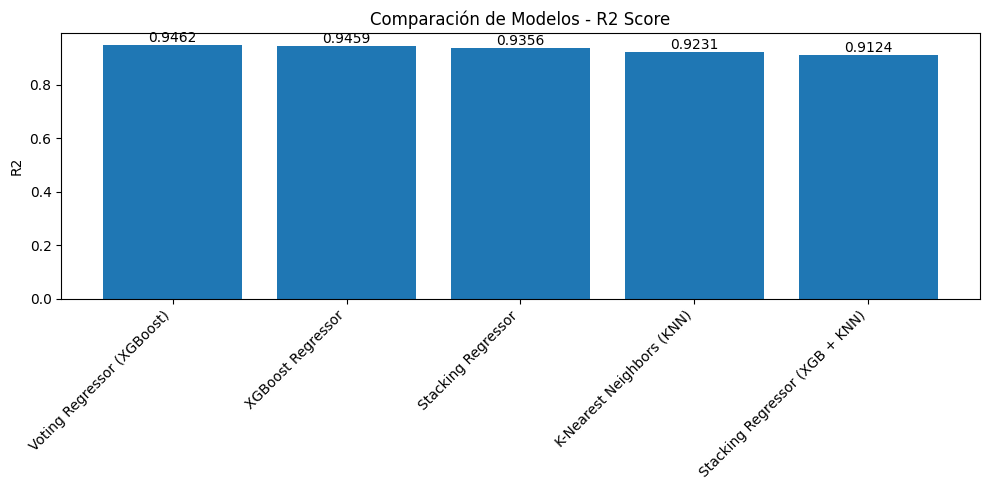

In [ ]:
#R2
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.bar(results_df["Model"], results_df["R2 Score"])

plt.xticks(rotation=45, ha='right')
plt.title("Comparación de Modelos - R2 Score")
plt.ylabel("R2")

# 🔥 Agregar valores encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

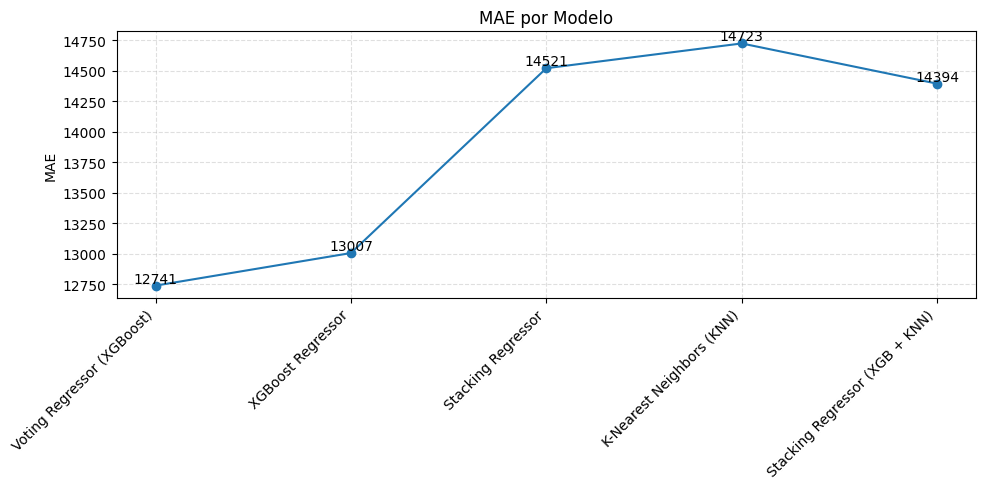

In [ ]:
#MAE

plt.figure(figsize=(10,5))

plt.plot(results_df["Model"], results_df["MAE"], marker='o')

plt.title("MAE por Modelo")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.4)

for i, v in enumerate(results_df["MAE"]):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

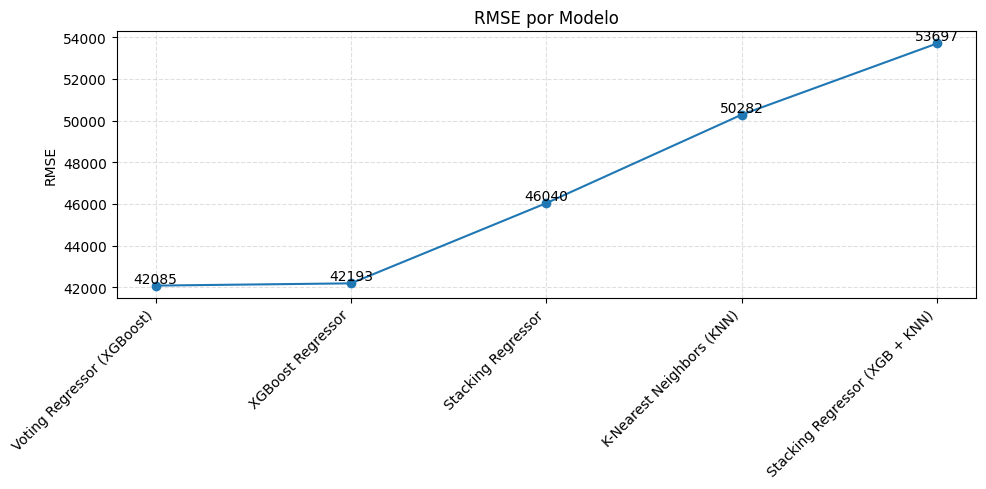

In [ ]:
#RMSE

plt.figure(figsize=(10,5))

plt.plot(results_df["Model"], results_df["RMSE"], marker='o')

plt.title("RMSE por Modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.4)

for i, v in enumerate(results_df["RMSE"]):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

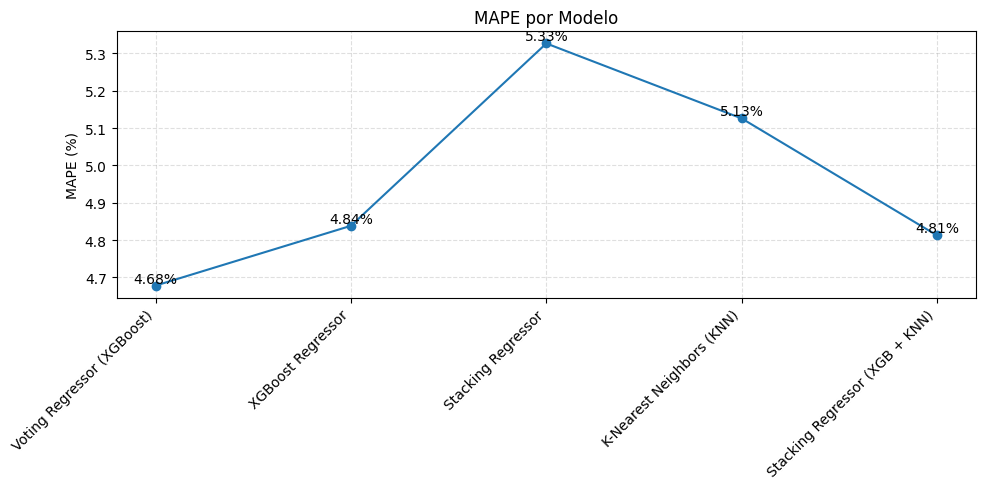

In [ ]:
#MAPE%

plt.figure(figsize=(10,5))

plt.plot(results_df["Model"], results_df["MAPE (%)"], marker='o')

plt.title("MAPE por Modelo")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.4)

for i, v in enumerate(results_df["MAPE (%)"]):
    plt.text(i, v, f"{v:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()

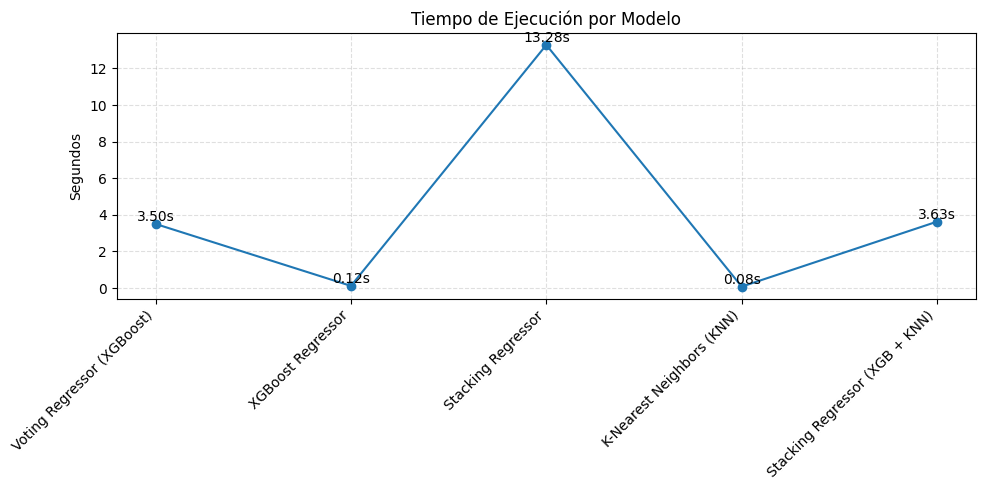

In [ ]:
#Tiempo de ejecucion

plt.figure(figsize=(10,5))

plt.plot(results_df["Model"], results_df["Execution Time (s)"], marker='o')

plt.title("Tiempo de Ejecución por Modelo")
plt.ylabel("Segundos")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.4)

for i, v in enumerate(results_df["Execution Time (s)"]):
    plt.text(i, v, f"{v:.2f}s", ha='center', va='bottom')

plt.tight_layout()
plt.show()

##CONCLUSION FINAL

##En este trabajo se evaluaron distintos modelos de aprendizaje automático para la predicción del valor de venta (MV), incluyendo KNN, Random Forest, Gradient Boosting, XGBoost, SVR, redes neuronales y técnicas de ensamble como Voting y Stacking. El objetivo fue identificar el modelo con mejor capacidad predictiva considerando métricas como R², MAE, RMSE y MAPE, además del tiempo de ejecución.

##Los mejores resultados se obtuvieron con el modelo de Voting Regressor basado en XGBoost, alcanzando un desempeño de R² = 0.9462, MAE = 12,740.77, RMSE = 42,084.97 y MAPE = 4.68%, lo que indica una alta precisión y un error porcentual bajo en la predicción del precio. De forma individual, XGBoost también mostró un rendimiento muy cercano con R² = 0.9459 y MAPE = 4.84%, confirmando que es el modelo más estable y robusto para este problema.

##Por otro lado, KNN también presentó buenos resultados con R² = 0.9231 y MAPE = 5.13%, lo que sugiere que existe una fuerte estructura basada en similitud entre observaciones dentro del dataset. Sin embargo, modelos como SVR y redes neuronales no lograron un buen desempeño, obteniendo incluso valores negativos de R², lo cual indica que no logran capturar adecuadamente la relación entre variables sin un ajuste más profundo o mayor ingeniería de características.

##En el caso de los modelos de ensamble heterogéneos, como el Stacking Regressor (KNN + XGBoost), no se observó una mejora significativa respecto a los modelos individuales. Este modelo obtuvo R² = 0.9124, MAE = 14,394.15 y MAPE = 4.81%, siendo inferior al Voting y al XGBoost individual. Esto puede explicarse porque ambos modelos base (KNN y XGBoost) aprenden patrones muy similares del dataset, lo que reduce la diversidad necesaria para que el stacking aporte mejoras. Además, el meta-modelo lineal (Ridge) tiende a suavizar las predicciones, lo que puede limitar el rendimiento final.

##En conclusión, el modelo más adecuado para este problema es el Voting Regressor basado en XGBoost, ya que ofrece el mejor balance entre precisión, estabilidad y error de predicción. Los resultados también muestran que el problema tiene una estructura parcialmente basada en similitud (lo que favorece a KNN) pero principalmente no lineal, lo que explica el dominio de los modelos basados en boosting.